# 02 · Attribution of tower filings

Who is behind each tower and monopole filing, and is it a new structure or work on one that already stands.
Reads `data/parquet/cases_enriched.parquet`, written by `py -m faa_oe enrich` (category, entity, `build_kind`,
project and FCC ASR fields). Only tower-signal filings (`TOWER`, `TOWER$ANTENNA`, `POLE$MONO`) are used.

In [1]:
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import polars as pl

from faa_oe import build_kind as bk
from faa_oe import enrich, entities
from faa_oe import viz

viz.apply_style()
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(160)
pl.Config.set_fmt_str_lengths(50)

# First month with complete coverage in the current pull; move back once the 2015+ backfill has landed.
START = date(2023, 10, 1)

tw = enrich.load_enriched(columns=enrich.TOWER_VIEW_COLUMNS + ["fcc_asr_number"] + list(bk.SIGNALS))
last_full_month = tw["date_entered"].max().replace(day=1)
in_window = (pl.col("date_entered") >= START) & (pl.col("date_entered") < last_full_month)
print(f"{tw.height:,} tower-signal filings, {tw['date_entered'].min()} → {tw['date_entered'].max()}; "
      f"charts use {START} → {last_full_month} (exclusive)")
entities.attribution_rate(tw)

73,585 tower-signal filings, 2022-01-02 → 2026-10-01; charts use 2023-10-01 → 2026-10-01 (exclusive)


n,n_attributed,rate,rate_sponsor_only,rate_listed
u32,u32,f64,f64,f64
73585,71170,0.967,0.931,0.646


## Attribution rate over time
Share of tower-signal filings with an entity, by month: any entity (sponsor rules, then the FCC ASR owner as
fallback), sponsor rules alone, and listed companies only (entity with a ticker). The 70% line is the target. The
listed share falls through 2026 as Crown Castle's and Verizon's filings drop while private tower companies
(Vertical Bridge above all) file more.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


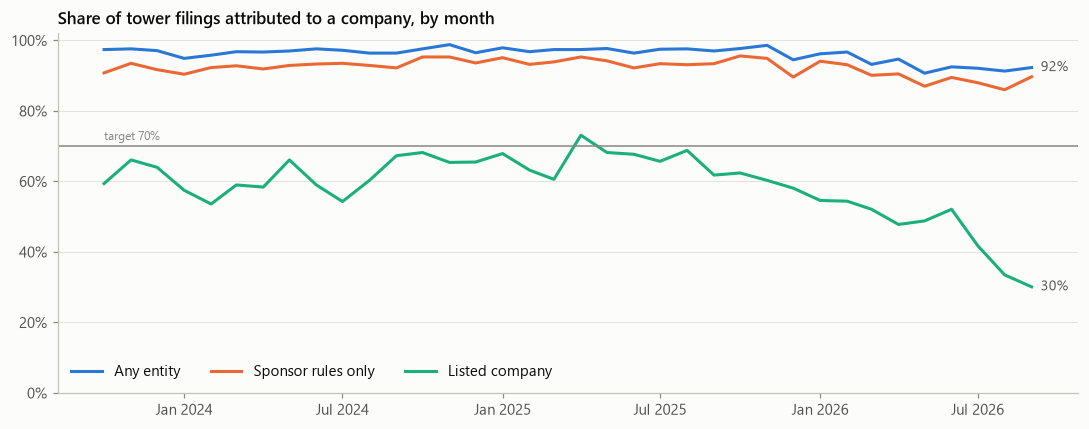

In [2]:
monthly = entities.attribution_rate(tw.filter(in_window), pl.col("date_entered").dt.truncate("1mo").alias("month"))
series = [("rate", "Any entity", viz.SERIES[0]), ("rate_sponsor_only", "Sponsor rules only", viz.SERIES[1]),
          ("rate_listed", "Listed company", viz.SERIES[2])]

fig, ax = plt.subplots(figsize=(10, 4))
for col, label, color in series:
    ax.plot(monthly["month"], monthly[col], color=color, label=label, linewidth=2)
for col in ("rate", "rate_listed"):  # the sponsor-only line ends too close to "any entity" to label
    ax.annotate(f"{monthly[col][-1]:.0%}", (monthly["month"][-1], monthly[col][-1]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=viz.INK_2)
ax.axhline(0.7, color=viz.MUTED, linewidth=1)
ax.annotate("target 70%", (monthly["month"][0], 0.7), xytext=(0, 4), textcoords="offset points", fontsize=8, color=viz.MUTED)
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_title("Share of tower filings attributed to a company, by month")
ax.legend(loc="lower left", ncols=3)
fig.tight_layout()

In [3]:
entities.attribution_rate(tw, pl.col("date_entered").dt.year().alias("year"))

year,n,n_attributed,rate,rate_sponsor_only,rate_listed
i32,u32,u32,f64,f64,f64
2022,6317,6233,0.987,0.971,0.883
2023,18780,18265,0.973,0.931,0.688
2024,15601,15120,0.969,0.932,0.618
2025,21328,20734,0.972,0.936,0.653
2026,11559,10818,0.936,0.902,0.473


## Who is left unattributed
The largest sponsors (normalised name) whose tower filings get no entity from either source. Mostly private
individuals and filing agents whose structures have no ASR registration to fall back on.

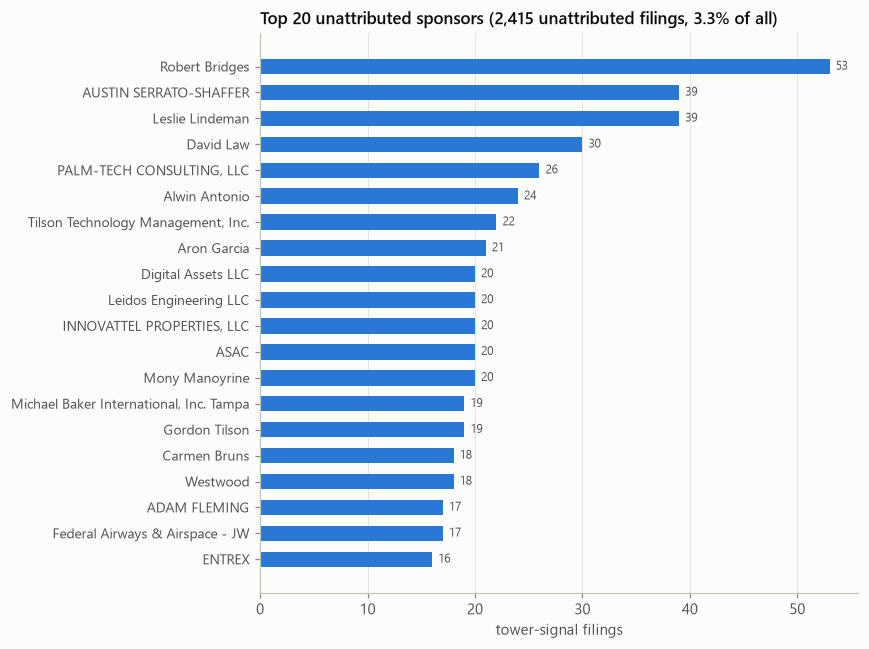

In [4]:
unmatched = entities.unmatched_report(tw, top=20)
fig, ax = plt.subplots(figsize=(8, 6))
y = list(range(unmatched.height))[::-1]
ax.barh(y, unmatched["n"], height=0.6, color=viz.SERIES[0])
ax.set_yticks(y, unmatched["example"].to_list(), fontsize=9)
for yi, n in zip(y, unmatched["n"]):
    ax.annotate(str(n), (n, yi), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8, color=viz.INK_2)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel("tower-signal filings")
n_un = tw.filter(pl.col("entity").is_null()).height
ax.set_title(f"Top 20 unattributed sponsors ({n_un:,} unattributed filings, {n_un / tw.height:.1%} of all)")
fig.tight_layout()

In [5]:
unmatched

sponsor_norm,n,example,consultant,share
str,u32,str,bool,f64
"""ROBERT BRIDGES""",53,"""Robert Bridges""",false,0.0007
"""AUSTIN SERRATO SHAFFER""",39,"""AUSTIN SERRATO-SHAFFER""",false,0.0005
"""LESLIE LINDEMAN""",39,"""Leslie Lindeman""",false,0.0005
"""DAVID LAW""",30,"""David Law""",false,0.0004
"""PALM TECH CONSULTING LLC""",26,"""PALM-TECH CONSULTING, LLC""",true,0.0004
"""ALWIN ANTONIO""",24,"""Alwin Antonio""",false,0.0003
"""TILSON TECHNOLOGY MANAGEMENT INC""",22,"""Tilson Technology Management, Inc.""",true,0.0003
"""ARON GARCIA""",21,"""Aron Garcia""",false,0.0003
"""DIGITAL ASSETS LLC""",20,"""Digital Assets LLC""",false,0.0003


## Tower filings per company: new builds vs modifications
Monthly tower-signal filings for the listed tower companies and carriers, plus the largest private builders.
`build_kind` comes from the ASR registration (registered or built before the filing → modification), the FAA
built date, description keywords and earlier filings at the same spot (see `build_kind.py`). Each panel has its
own y-scale.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


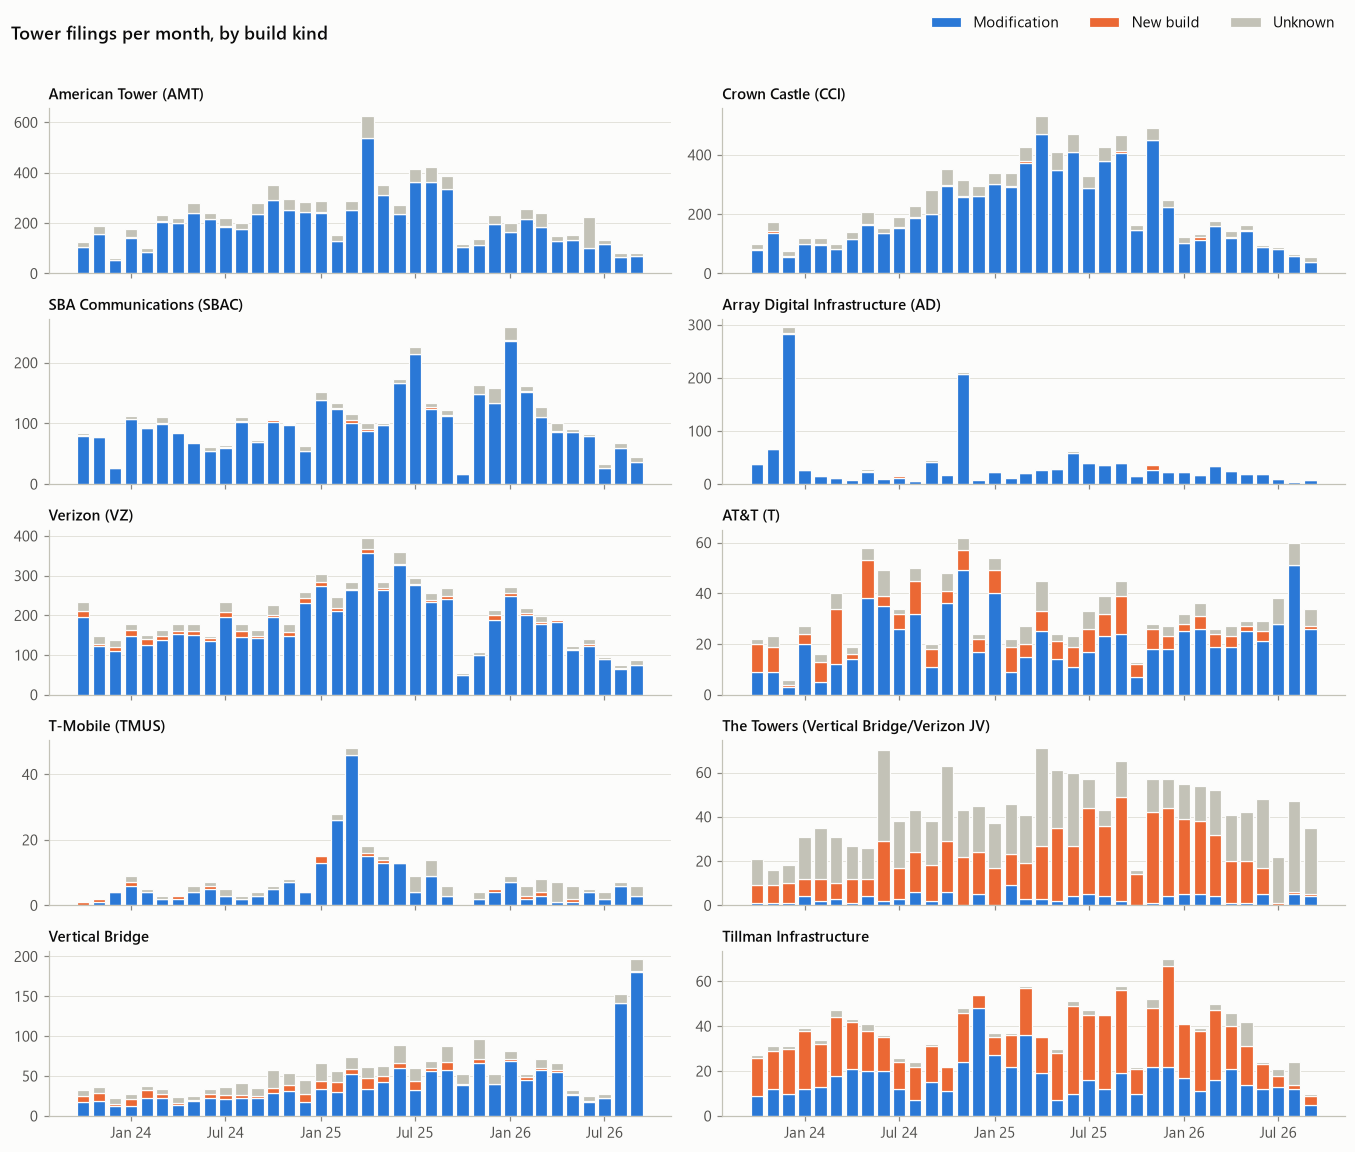

In [6]:
PANELS = ["American Tower", "Crown Castle", "SBA Communications", "Array Digital Infrastructure", "Verizon", "AT&T",
          "T-Mobile", "The Towers (Vertical Bridge/Verizon JV)", "Vertical Bridge", "Tillman Infrastructure"]
KIND_COLORS = {"modification": viz.SERIES[0], "new_build": viz.SERIES[1], "unknown": viz.OTHER}
KIND_LABELS = {"modification": "Modification", "new_build": "New build", "unknown": "Unknown"}

m = enrich.monthly_by_entity(tw.filter(in_window), PANELS)
fig, axes = viz.small_multiples(len(PANELS), ncols=2, panel=(6.2, 2.1), sharex=True)
for ax, name in zip(axes, PANELS):
    d = m.filter(pl.col("entity") == name)
    months = d.filter(pl.col("build_kind") == "modification")["month"].to_list()
    layers = [d.filter(pl.col("build_kind") == k)["n"].to_list() for k in enrich.BUILD_KINDS]
    viz.stacked_columns(ax, months, layers, [KIND_COLORS[k] for k in enrich.BUILD_KINDS], width=24,
                        labels=[KIND_LABELS[k] for k in enrich.BUILD_KINDS])
    ticker = tw.filter(pl.col("entity") == name)["ticker"].drop_nulls().first()
    ax.set_title(f"{name} ({ticker})" if ticker else name, fontsize=10)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncols=3, bbox_to_anchor=(0.99, 1.0))
fig.suptitle("Tower filings per month, by build kind", x=0.01, ha="left", fontweight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.97))

In [7]:
enrich.entity_year_table(tw.filter(pl.col("entity").is_in(PANELS)), listed_only=False)

entity,ticker,year,modification,new_build,unknown
str,str,i32,u32,u32,u32
"""AT&T""","""T""",2022,170,29,61
"""AT&T""","""T""",2023,184,129,44
"""AT&T""","""T""",2024,295,99,53
"""AT&T""","""T""",2025,221,98,61
"""AT&T""","""T""",2026,240,24,47
"""American Tower""","""AMT""",2022,291,0,84
"""American Tower""","""AMT""",2023,2995,17,437
"""American Tower""","""AMT""",2024,2477,14,390
"""American Tower""","""AMT""",2025,3181,6,495


### How the build-kind signals agree
Each signal fires on some filings; where two fire on the same filing, how often they point the same way.

In [8]:
sig = tw.select("asn", *bk.SIGNALS)
display(bk.signal_coverage(sig))
display(bk.signal_agreement(sig).filter(pl.col("n_both") > 0))
tw.group_by("build_kind", "build_kind_basis").len("n").sort("n", descending=True)

signal,n_existing,n_new,share_fired
str,i64,i64,f64
"""bk_asr""",49699,8442,0.79
"""bk_faa_built""",791,0,0.011
"""bk_keyword""",1692,0,0.023
"""bk_prior_case""",5984,0,0.081
"""bk_asr_number""",54,0,0.001


signal_a,signal_b,n_both,n_agree,agree_rate
str,str,i64,i64,f64
"""bk_asr""","""bk_faa_built""",701,677,0.966
"""bk_asr""","""bk_keyword""",1475,1425,0.966
"""bk_asr""","""bk_prior_case""",5136,4337,0.844
"""bk_faa_built""","""bk_keyword""",9,9,1.0
"""bk_faa_built""","""bk_prior_case""",63,63,1.0
"""bk_keyword""","""bk_prior_case""",108,108,1.0
"""bk_prior_case""","""bk_asr_number""",2,2,1.0


build_kind,build_kind_basis,n
str,str,u32
"""modification""","""asr""",49699
"""unknown""","""none""",14269
"""new_build""","""asr""",8442
"""modification""","""prior_case""",818
"""modification""","""keyword""",215
"""modification""","""faa_built""",90
"""modification""","""asr_number""",52


## Filing to construction
For new builds whose ASR registration carries a construction date: days from the FAA filing (`date_entered`)
to the date the structure was reported built. Recent filings have not had time to be built, so the
distribution is censored on the right.

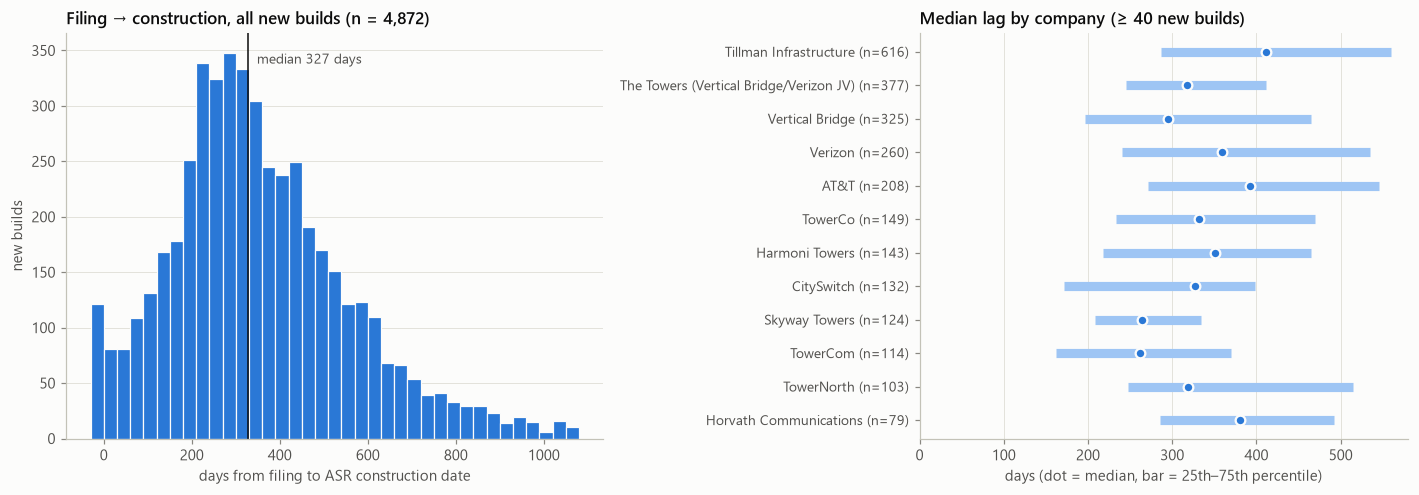

In [9]:
lags = tw.filter(pl.col("filing_to_construction_days").is_not_null() & (pl.col("filing_to_construction_days") >= -30))
overall = enrich.lag_summary(lags, by=None).row(0, named=True)
by_entity = enrich.lag_summary(lags, by="entity", min_n=40).head(12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})
ax1.hist(lags["filing_to_construction_days"], bins=range(-30, 1100, 30), color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=0.8)
ax1.axvline(overall["median_days"], color=viz.INK, linewidth=1)
ax1.annotate(f"median {overall['median_days']:.0f} days", (overall["median_days"], ax1.get_ylim()[1] * 0.95), xytext=(6, 0),
             textcoords="offset points", fontsize=9, color=viz.INK_2, va="top")
ax1.set_xlabel("days from filing to ASR construction date")
ax1.set_ylabel("new builds")
ax1.set_title(f"Filing → construction, all new builds (n = {lags.height:,})")

d = by_entity.reverse()
y = list(range(d.height))
ax2.hlines(y, d["p25_days"], d["p75_days"], color=viz.BLUE_RAMP[1], linewidth=6)
ax2.scatter(d["median_days"], y, s=40, color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=1.5, zorder=3)
ax2.set_yticks(y, [f"{e} (n={n})" for e, n in zip(d["entity"], d["n"])], fontsize=9)
ax2.grid(axis="y", visible=False)
ax2.grid(axis="x", visible=True)
ax2.set_xlim(0, None)
ax2.set_xlabel("days (dot = median, bar = 25th–75th percentile)")
ax2.set_title("Median lag by company (≥ 40 new builds)")
fig.tight_layout()

In [10]:
by_entity

entity,n,median_days,p25_days,p75_days
str,u32,f64,f64,f64
"""Tillman Infrastructure""",616,411.0,287.0,560.0
"""The Towers (Vertical Bridge/Verizon JV)""",377,317.0,245.0,411.0
"""Vertical Bridge""",325,295.0,196.0,465.0
"""Verizon""",260,358.5,240.0,535.0
"""AT&T""",208,392.5,271.0,546.0
"""TowerCo""",149,332.0,233.0,469.0
"""Harmoni Towers""",143,351.0,218.0,465.0
"""CitySwitch""",132,327.0,172.0,398.0
"""Skyway Towers""",124,264.0,208.0,334.0


## ASR match coverage
How tower-signal filings were tied to an FCC registration: the case's own ASR number, the FAA study number
recorded on the registration, or a registration within 50 m with matching height.

In [11]:
tw.group_by("asr_match_method").len("n").with_columns(share=(pl.col("n") / tw.height).round(3)).sort("n", descending=True)

asr_match_method,n,share
str,u32,f64
"""asr_number""",54428,0.74
null,15444,0.21
"""proximity""",3687,0.05
"""faa_study""",26,0.0
